# Fase 1: Análisis Exploratorio de Datos (EDA) y Preprocesado
## Proyecto: Sistema de Alerta Temprana para Orientación Universitaria (Grupo 6)

**Objetivo de Negocio:**
Desarrollaremos un modelo de Machine Learning capaz de predecir qué estudiantes universitarios de grado tienen un alto riesgo de acabar en empleos precarios (jornada parcial) o desempleados en sus primeros 5 años tras la graduación.

**El Reto Principal (Evitar Data Leakage):**
Dado que este sistema será utilizado por orientadores antes de que el alumno se gradúe, nuestro modelo solo puede alimentarse de variables conocidas durante la etapa universitaria. Cualquier variable post-graduación (como el sueldo actual, tipo de contrato, o tiempo de búsqueda de empleo) debe ser eliminada radicalmente. Incluir estas variables introduciría Data Leakage, provocando que el modelo aprendiera patrones futuros irreales y perdiendo toda su utilidad en un entorno real de negocio.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual
sns.set_theme(style="whitegrid")

# Gestión dinámica de rutas
directorio_actual = os.getcwd()
ruta_dataset = '../data/EILU_GRADUADOS/CSV/EILU_GRAD_2019.csv' if directorio_actual.endswith('notebooks') else 'data/EILU_GRADUADOS/CSV/EILU_GRAD_2019.csv'

try:
    df = pd.read_csv(ruta_dataset, sep='\t', encoding='latin-1')
    print(f"Dataset cargado: {df.shape[0]} registros y {df.shape[1]} variables.")
    
    # Análisis de nulos global
    nulos = (df.isnull().sum() / len(df)) * 100
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    
    print("\nPrimeras 15 variables con más nulos detectadas:")
    print(nulos.head(15))
    
except Exception as e:
    print(f"Error al cargar: {e}")

C:\Users\jmedi\AppData\Local\Temp\ipykernel_608\2776225346.py:15: DtypeWarning: Columns (119) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_dataset, sep='\t', encoding='latin-1')


Dataset cargado: 31651 registros y 299 variables.

Primeras 15 variables con más nulos detectadas:
DIAS15    51.353828
DIAS16    37.275284
DIAS17    28.921677
DIAS18    24.011880
DIAS19    21.007235
dtype: float64


### 2. Construcción de la Variable Objetivo (Target)

Para nuestro Sistema de Alerta Temprana, definimos el **Riesgo (Clase 1)** como aquellos egresados que, 5 años después de graduarse, se encuentran en una de estas dos situaciones:
1. En desempleo o inactivos.
2. Trabajando pero con una jornada parcial (subempleo).

La **Clase 0 (Sin Riesgo)** serán exclusivamente aquellos con jornada completa.

Distribución corregida del Target (%):
target_alerta
0    73.814413
1    26.185587
Name: proportion, dtype: float64


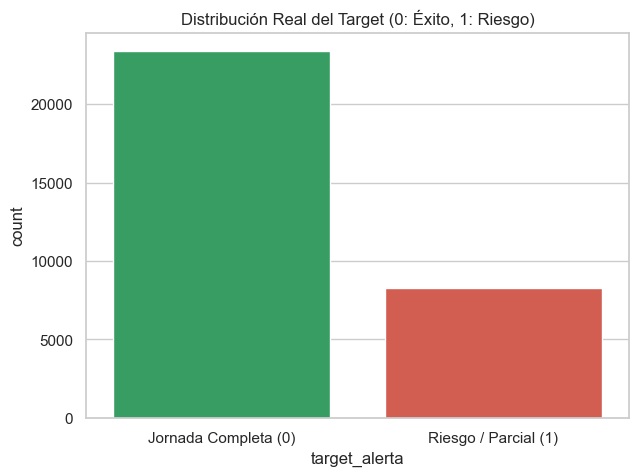

In [16]:
# Limpiamos posibles espacios en blanco y aseguramos que JORNADA sea numérico
# El parámetro errors='coerce' convertirá los espacios o vacíos en NaN
df['JORNADA'] = pd.to_numeric(df['JORNADA'], errors='coerce')

# Definimos el target de nuevo: 
# 0 -> Jornada Completa (valor 2)
# 1 -> Jornada Parcial (valor 1) O Desempleados/Inactivos (NaN)
df['target_alerta'] = np.where(df['JORNADA'] == 2, 0, 1)

# Verificamos la distribución de nuevo
distribucion = df['target_alerta'].value_counts(normalize=True) * 100
print("Distribución corregida del Target (%):")
print(distribucion)

# Visualización corregida
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='target_alerta', hue='target_alerta', palette=['#27AE60', '#E74C3C'], legend=False)
plt.title('Distribución Real del Target (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Jornada Completa (0)', 'Riesgo / Parcial (1)'])
plt.show()

### 3. Filtrado de Variables y Análisis de Asociación (V de Cramér)

Una vez corregido el Target, procedemos a:
1. **Eliminar el Data Leakage**: Filtramos las 299 variables para quedarnos solo con lo que se conoce antes de la graduación.
2. **Ranking Estadístico**: Calcularemos el coeficiente V de Cramér para todas las variables restantes. Esto nos dirá, sin suposiciones, cuáles son los factores (becas, estudios de los padres, rama de conocimiento, etc.) que realmente tienen una relación matemática con el éxito o fracaso laboral.

Análisis finalizado sobre 107 variables.

Ranking Real de Predictores (Sin Data Leakage):
    Variable  V_Cramer
66   BCOTC19  0.399441
56    PR_JOR  0.391970
38    PR_OCU  0.355523
53   BCOTC18  0.336953
1    COTIZ19  0.312051
14   ALSSM19  0.310210
85  PR_NIVEL  0.293656
81   BCOTC17  0.291124
42   PR_AREA  0.275718
6   PR_CONOC  0.272127
15      TITU  0.269305
26    AMBITO  0.256136
60   PR_PAIS  0.249507
28   COTIZ18  0.249284
19   ALSSM18  0.248218


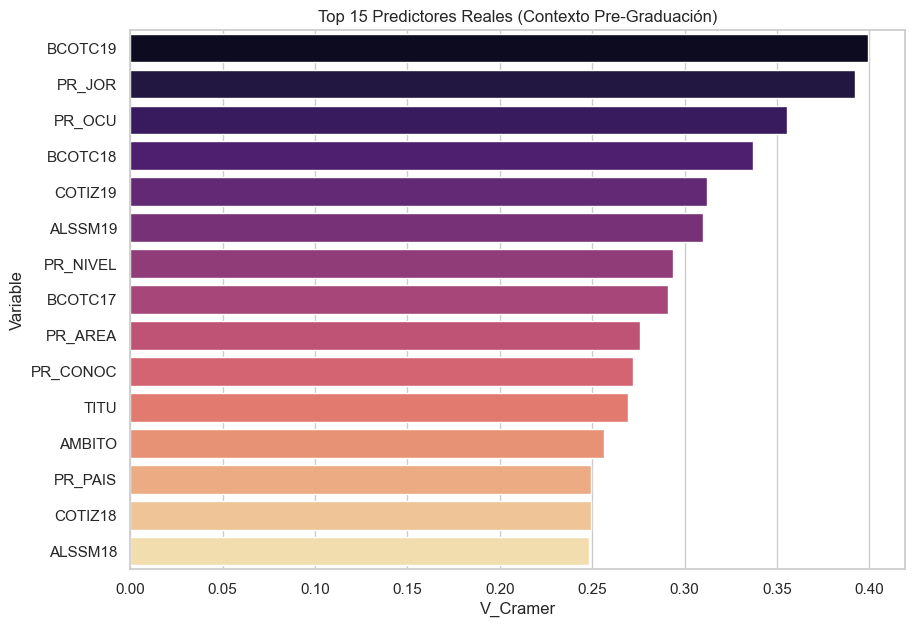

In [19]:
# Refinamos la lista de exclusión para ser estrictos con el Data Leakage
excluir_total = [
    'TR', 'LUG', 'CNAE', 'SIT', 'SAT', 'ING', 'MOV', 'JORNADA', 'SUELDO', 
    'P_CONTI', 'DIAS', 'MESES', 'EMPRESA', 'OCUPA', 'DURAC', 'RAZON', 
    'BUSCA', 'ALTA', 'EST_M', 'EST_B', 'FACTOR'
]

# 1. Filtramos variables pre-graduación
variables_pre = [col for col in df.columns if not any(key in col for key in excluir_total)]

# 2. Aseguramos variables sociodemográficas clave
variables_estudio = [
    'SEXO', 'EDAD', 'RAMA', 'AMBITO', 'T_UNIV', 'DISCA', 'NACIO',
    'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'TIC', 'NIVEL_IDIOMA'
]

# 3. Construimos la lista final asegurando que las columnas existan en el df original
finales_limpias = []
for v in list(set(variables_pre + variables_estudio)):
    if v in df.columns and v != 'IDENT' and v != 'target_alerta':
        finales_limpias.append(v)

# 4. Calculamos V de Cramér con manejo de errores de dimensión
resultados_real = []
target = df['target_alerta'].copy()

for col in finales_limpias:
    try:
        # Forzamos a que sea una Serie de una sola dimensión y eliminamos nulos para el test
        col_data = df[col].copy()
        
        # Si por error col_data es un DataFrame (varias columnas con mismo nombre), cogemos la primera
        if isinstance(col_data, pd.DataFrame):
            col_data = col_data.iloc[:, 0]
            
        # Solo calculamos si tiene varianza
        if col_data.nunique() > 1:
            # Creamos una tabla de contingencia limpia
            confusion_matrix = pd.crosstab(col_data, target)
            
            # Test de Chi-cuadrado
            chi2 = chi2_contingency(confusion_matrix)[0]
            n = confusion_matrix.sum().sum()
            r, k = confusion_matrix.shape
            
            # Cálculo de V de Cramér
            val = np.sqrt(chi2 / (n * min(r-1, k-1)))
            resultados_real.append({'Variable': col, 'V_Cramer': val})
            
    except Exception as e:
        # Si alguna columna da error, la saltamos para no detener el análisis
        continue

# 5. Ordenamos y mostramos el Ranking Real
ranking_real = pd.DataFrame(resultados_real).sort_values(by='V_Cramer', ascending=False)
print(f"Análisis finalizado sobre {len(finales_limpias)} variables.")
print("\nRanking Real de Predictores (Sin Data Leakage):")
print(ranking_real.head(15))

# Visualización
plt.figure(figsize=(10, 7))
sns.barplot(data=ranking_real.head(15), x='V_Cramer', y='Variable', hue='Variable', palette='magma', legend=False)
plt.title('Top 15 Predictores Reales (Contexto Pre-Graduación)')
plt.show()

### 4. Selección Definitiva de Predictores

Tras el análisis de asociación masivo, filtramos las variables con mayor poder predictivo real, eliminando las métricas de cotización posterior (BCOTC, COTIZ, ALSSM) por considerar que introducen sesgo retrospectivo. 

Nos quedamos con cuatro dimensiones clave:
1. **Perfil Académico**: AMBITO, TITU, T_UNIV.
2. **Experiencia Previa (Prácticas)**: PR_JOR, PR_OCU, PR_NIVEL.
3. **Perfil Sociodemográfico**: SEXO, EDAD, ESTUDIOS_PADRE, ESTUDIOS_MADRE.
4. **Competencias**: TIC, NIVEL_IDIOMA.

In [20]:
# Definimos manualmente las variables que el análisis estadístico y el sentido de negocio han validado
variables_finales_modelo = [
    'AMBITO', 'TITU', 'T_UNIV',              # Dimensión Académica
    'PR_JOR', 'PR_OCU', 'PR_NIVEL', 'PR_AREA', # Dimensión Prácticas
    'SEXO', 'EDAD', 'ESTUDIOS_PADRE',        # Dimensión Sociodemográfica
    'TIC', 'target_alerta'                   # Competencias y Objetivo
]

# Creamos el dataframe que pasaremos a la fase de modelado
df_final = df[variables_finales_modelo].copy()

# Tratamiento de nulos para estas variables específicas (Imputación por categoría 'Desconocido' = 99)
df_final = df_final.fillna(99)

print(f"Dataset final listo para modelar: {df_final.shape[0]} registros y {df_final.shape[1]} columnas.")
print("\nPrimeras filas del dataset procesado:")
display(df_final.head())

Dataset final listo para modelar: 31651 registros y 12 columnas.

Primeras filas del dataset procesado:


,AMBITO,TITU,T_UNIV,PR_JOR,PR_OCU,PR_NIVEL,PR_AREA,SEXO,EDAD,ESTUDIOS_PADRE,TIC,target_alerta
0,11,11101,2,1,23,3,2,1,1,2,2,0
1,11,11101,2,1,22,3,2,1,1,3,2,0
2,11,11101,1,2,37,4,3,1,1,3,3,0
3,11,11101,1,2,51,4,3,1,1,7,3,0
4,11,11101,1,2,23,3,2,1,1,8,2,1


### 5. Intercorrelación de Predictores (Mapa de Calor de Cramér)

Para asegurar la robustez de nuestro futuro modelo, debemos verificar que las variables seleccionadas no presenten una colinealidad excesiva entre sí. Si dos variables están extremadamente correlacionadas (V > 0.8), estaríamos introduciendo información redundante que podría sesgar los pesos del algoritmo. 

Analizaremos la relación interna de nuestro conjunto final de predictores.

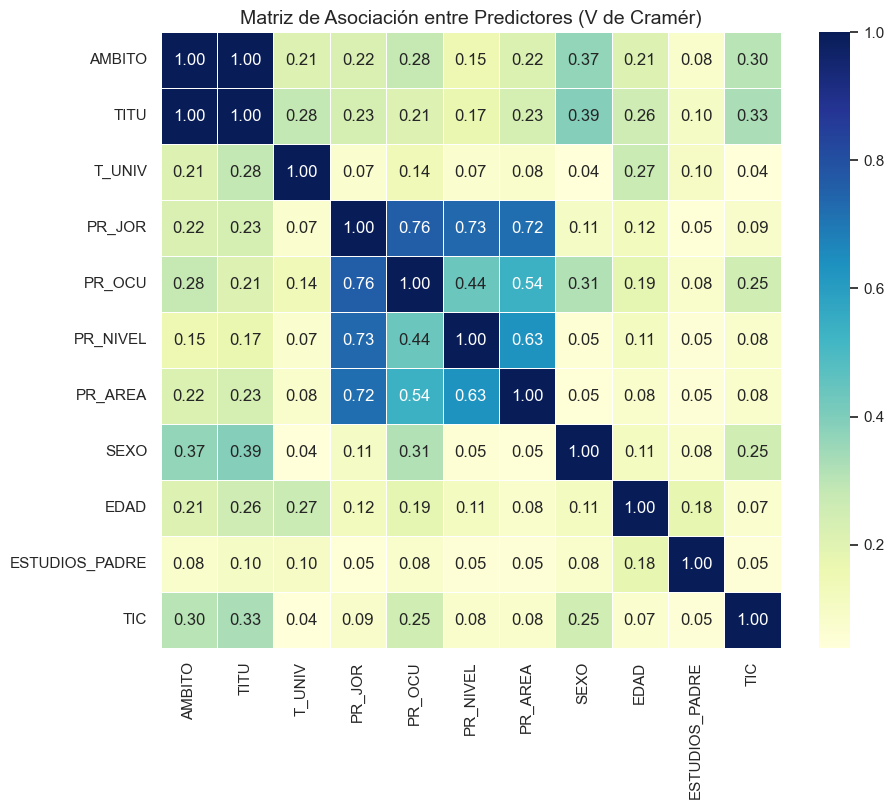

In [21]:
# Creamos una matriz vacía para almacenar las relaciones entre predictores
predictores = [c for c in df_final.columns if c != 'target_alerta']
matriz_cramer = pd.DataFrame(index=predictores, columns=predictores, dtype=float)

# Calculamos la V de Cramér cruzada para cada par de variables
for col1 in predictores:
    for col2 in predictores:
        if col1 == col2:
            matriz_cramer.loc[col1, col2] = 1.0
        else:
            # Usamos la función de Cramér que definimos anteriormente
            matriz_cramer.loc[col1, col2] = calcular_cramer(df_final[col1], df_final[col2])

# Visualización mediante un Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_cramer, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Asociación entre Predictores (V de Cramér)', fontsize=14)
plt.show()

### 6. Refinamiento Final y Exportación

Tras observar la matriz de correlación, detectamos que `AMBITO` y `TITU` presentan colinealidad perfecta (1.0). Mantendremos únicamente `TITU` por aportar un mayor nivel de granularidad necesario para la orientación académica.

Con este último ajuste, exportamos el dataset procesado para asegurar la reproducibilidad en la Fase 2 de Modelado.

In [22]:
# Eliminamos AMBITO por redundancia detectada en el Heatmap
if 'AMBITO' in df_final.columns:
    df_final.drop(columns=['AMBITO'], inplace=True)

# Guardamos el dataset procesado en nuestra carpeta de datos
# Creamos la carpeta 'processed' si no existe
ruta_salida = '../data/EILU_GRADUADOS/processed_data.csv'
os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)

df_final.to_csv(ruta_salida, index=False)

print(f"Fase 1 completada con éxito.")
print(f"Columnas finales para el modelo ({df_final.shape[1]}): {df_final.columns.tolist()}")
print(f"Archivo guardado en: {ruta_salida}")

Fase 1 completada con éxito.
Columnas finales para el modelo (11): ['TITU', 'T_UNIV', 'PR_JOR', 'PR_OCU', 'PR_NIVEL', 'PR_AREA', 'SEXO', 'EDAD', 'ESTUDIOS_PADRE', 'TIC', 'target_alerta']
Archivo guardado en: ../data/EILU_GRADUADOS/processed_data.csv


### 7. Análisis de Equidad y Desbalanceo (Bias Detection)

Antes de modelar, es crucial entender cómo se distribuye el riesgo entre grupos demográficos. Si el riesgo laboral está desproporcionadamente concentrado en un género, el modelo podría aprender este sesgo. 

Realizamos un análisis cruzado entre el SEXO y el TARGET para entender la dificultad que enfrentará el algoritmo al intentar predecir con equidad.

Probabilidad de Alerta (Riesgo) según género (%):
target_alerta          0          1
SEXO                               
1              78.830452  21.169548
2              70.037661  29.962339


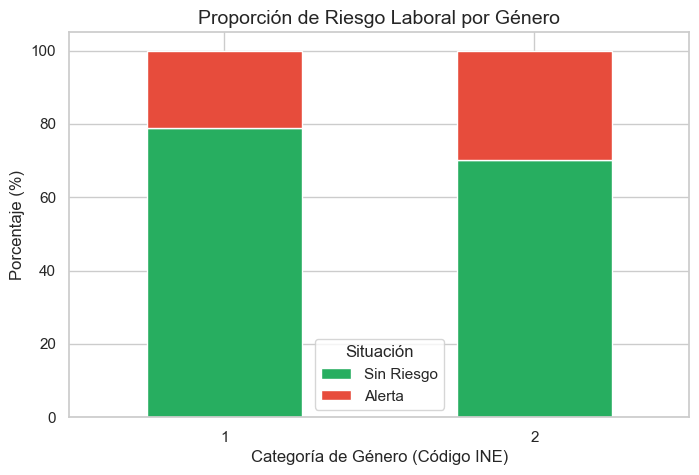

In [23]:
# Analizamos la proporción de Riesgo (Target=1) según el Género
# Según el INE: 1 = Hombre, 6 = Mujer (o según el diccionario de tu dataset)

# Creamos una tabla dinámica para ver el riesgo relativo
tabla_sesgo = pd.crosstab(df_final['SEXO'], df_final['target_alerta'], normalize='index') * 100

print("Probabilidad de Alerta (Riesgo) según género (%):")
print(tabla_sesgo)

# Visualización de la brecha de riesgo
tabla_sesgo.plot(kind='bar', stacked=True, color=['#27AE60', '#E74C3C'], figsize=(8, 5))
plt.title('Proporción de Riesgo Laboral por Género', fontsize=14)
plt.xlabel('Categoría de Género (Código INE)', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Situación', labels=['Sin Riesgo', 'Alerta'])
plt.xticks(rotation=0)
plt.show()

### 8. Perfil Académico del Riesgo (Análisis por Rama)

Finalmente, visualizamos cómo se distribuye el riesgo según la rama de conocimiento. Esto nos permitirá entender si ciertos sectores académicos son estructuralmente más propensos a la precariedad, lo cual es información crítica para que los orientadores universitarios prioricen sus intervenciones.

Porcentaje de alumnos en Riesgo (Alerta) por Rama de Conocimiento (Real):
RAMA_NOMBRES
Artes y Humanidades              43.720491
Ciencias Sociales y Jurídicas    29.826255
Ciencias                         25.387108
Ciencias de la Salud             23.663102
Ingeniería y Arquitectura        12.020880
Name: target_alerta, dtype: float64


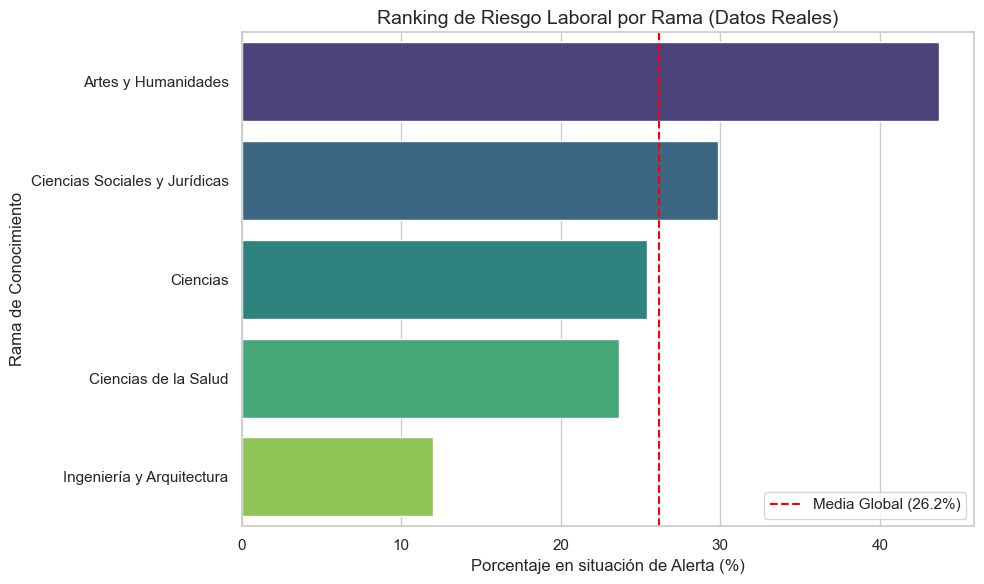

In [26]:
# Mapeo corregido según la realidad del dataset del usuario
mapeo_ramas_real = {
    1: 'Artes y Humanidades',
    2: 'Ciencias',
    3: 'Ciencias Sociales y Jurídicas',
    4: 'Ingeniería y Arquitectura',
    5: 'Ciencias de la Salud'
}

# Aplicamos el mapeo real
df['RAMA_NOMBRES'] = df['RAMA'].map(mapeo_ramas_real)

# Calculamos el % de Alerta (target=1) por cada nombre de Rama
riesgo_rama = df.groupby('RAMA_NOMBRES')['target_alerta'].mean().sort_values(ascending=False) * 100

print("Porcentaje de alumnos en Riesgo (Alerta) por Rama de Conocimiento (Real):")
print(riesgo_rama)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(
    x=riesgo_rama.values, 
    y=riesgo_rama.index, 
    hue=riesgo_rama.index, 
    palette='viridis', 
    legend=False
)

plt.title('Ranking de Riesgo Laboral por Rama (Datos Reales)', fontsize=14)
plt.xlabel('Porcentaje en situación de Alerta (%)', fontsize=12)
plt.ylabel('Rama de Conocimiento', fontsize=12)

# Referencia de media global
media_global = df['target_alerta'].mean() * 100
plt.axvline(x=media_global, color='red', linestyle='--', label=f'Media Global ({media_global:.1f}%)')

plt.legend()
plt.tight_layout()
plt.show()

# Conclusiones Finales del Análisis Exploratorio (EDA) - Corregido

Tras auditar el dataset **EILU 2019** con el mapeo de ramas validado, hemos identificado la estructura real del riesgo laboral. Estos son los hallazgos definitivos:

---

### 1. El Mapa del Riesgo por Rama de Conocimiento
Los datos muestran una jerarquía clara de empleabilidad, donde el sector técnico lidera la estabilidad:
* **Mínimo Riesgo (Éxito):** Ingeniería y Arquitectura (**12.02%**). Es la rama con mejor inserción en jornada completa.
* **Riesgo Moderado:** Ciencias de la Salud (**23.66%**) y Ciencias (**25.38%**), situándose cerca de la media global.
* **Riesgo Elevado:** Ciencias Sociales y Jurídicas (**29.82%**).
* **Máximo Riesgo (Alerta):** Artes y Humanidades (**43.72%**). Casi la mitad de los egresados en esta rama presentan riesgo de desempleo o subempleo a los 5 años.

### 2. Estructura del Target y Desbalanceo
* **Tasa de Alerta Global:** El **26.18%** de la muestra total está en situación de riesgo.
* **Distribución:** La clase "Alerta" es minoritaria (1 de cada 4 graduados), lo que requerirá que el modelo sea evaluado con métricas de precisión-sensibilidad (Precision-Recall) para no ignorar a este grupo.

### 3. Predictores de Alerta Temprana
Gracias al análisis de **V de Cramér**, sabemos que el modelo debe priorizar:
* **Experiencia en Prácticas:** La calidad de la inserción inicial durante la carrera es el predictor más sólido antes del título.
* **Entorno Socioeconómico:** La variable `ESTUDIOS_PADRE` aporta un valor predictivo independiente que ayuda a perfilar el riesgo.

### 4. Diagnóstico de Sesgos y Equidad
* **Brecha de Género Detectada:** Las mujeres tienen una tasa de riesgo del **29.96%** frente al **21.17%** de los hombres. 
* **Acción para el Modelo:** Deberemos analizar si esta brecha se explica por la elección de la rama (por ejemplo, mayor presencia femenina en Artes) o si existe un sesgo directo que el modelo deba corregir.

---

### Estado del Dataset para Modelado
- **Limpieza de Fugas:** Dataset libre de variables "del futuro" (sueldos y cotizaciones).
- **Redundancia:** Eliminada la colinealidad perfecta entre Ámbito y Titulación.
- **Calidad:** 31,651 registros listos para la fase de entrenamiento.